In [2]:
import sys
sys.path.append('../../../../../src')
sys.path.append('../../../../..')

import os
from PIL import ImageFont
import matplotlib.pyplot as plt
import numpy as np
from palette.symbol2value import get_asciis
from image.processing import DITHER_MODES
from converters.tile.nearest import Tile2SymbNearest

from tests.experimental.converters.test_loop import Params, test_loop

SYMBOLS = get_asciis()
FONT_PATH = "../../../../../fonts/CascadiaMono.ttf"
FONT_SIZE = 11
IMG_SET_PATH = "../../../../../imgs/BSDS500"
IMG_PATHS = [os.path.join(IMG_SET_PATH, img_name)
             for img_name in os.listdir(IMG_SET_PATH)[:5]]

def make_converter(params: Params):
    return Tile2SymbNearest(
        symbols=SYMBOLS,
        font=ImageFont.truetype(params.font_path, params.font_size),
        **params.converter_args)

Min: 0.0696 | Max: 0.4212 | Mean: 0.1988 | Std: 0.1344
Min: 0.0668 | Max: 0.2477 | Mean: 0.1378 | Std: 0.0660
Min: 0.0853 | Max: 0.3292 | Mean: 0.1823 | Std: 0.0921
Min: 0.0653 | Max: 0.2689 | Mean: 0.1511 | Std: 0.0858
Min: 0.0208 | Max: 0.2470 | Mean: 0.1121 | Std: 0.0762
Min: 0.1038 | Max: 0.1515 | Mean: 0.1249 | Std: 0.0172
Min: 0.0238 | Max: 0.1593 | Mean: 0.0924 | Std: 0.0532
Min: 0.0684 | Max: 0.1221 | Mean: 0.0935 | Std: 0.0233
Min: 0.0747 | Max: 0.1101 | Mean: 0.0905 | Std: 0.0143
Min: 0.1123 | Max: 0.1537 | Mean: 0.1285 | Std: 0.0172
Min: 0.0980 | Max: 0.1884 | Mean: 0.1383 | Std: 0.0316


C:\Users\wojte\AppData\Local\Temp\ipykernel_21196\589972136.py:27: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(similarity_scores,


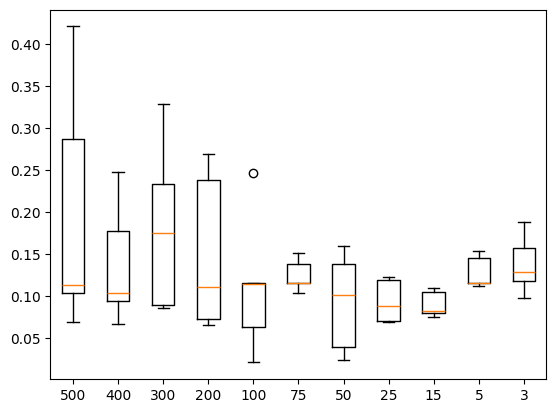

In [3]:
# window width

params_space = [
    w for w in range(500, 100, -100)
]
params_space += [
    w for w in range(100, 25, -25)
]
params_space += [
    w for w in range(25, 5, -10)
]
params_space += [
    w for w in range(5, 2, -2)
]

params_space = list(
    map(lambda w: Params(
        win_width=w,
        font_path=FONT_PATH,
        font_size=FONT_SIZE,
        converter_args={},
        preprocess_args={}),
        params_space))

similarity_scores = test_loop(IMG_PATHS, make_converter, params_space)

plt.boxplot(similarity_scores,
            labels=[param.win_width for param in params_space])
plt.show()

Min: 0.1123 | Max: 0.1537 | Mean: 0.1285 | Std: 0.0172
Min: 0.0690 | Max: 0.0960 | Mean: 0.0829 | Std: 0.0093
Min: 0.0690 | Max: 0.0960 | Mean: 0.0829 | Std: 0.0093


C:\Users\wojte\AppData\Local\Temp\ipykernel_21196\3146439082.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(similarity_scores,


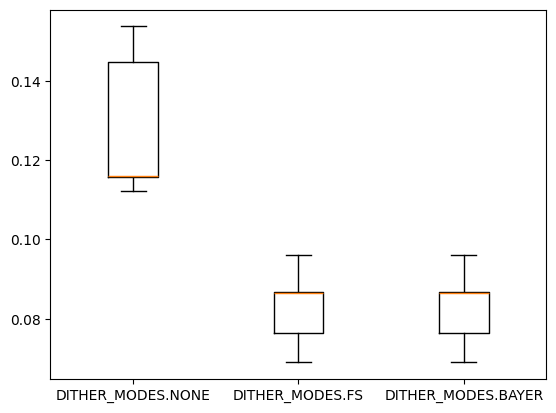

In [4]:
# dithering

params_space = [
    {'quantize_colors': 256, 'dither': DITHER_MODES.NONE},
    {'quantize_colors': 2, 'dither': DITHER_MODES.FS},
    {'quantize_colors': 2, 'dither': DITHER_MODES.BAYER}
]

params_space = list(
    map(lambda preprocess_args: Params(
        win_width=5,
        font_path=FONT_PATH,
        font_size=FONT_SIZE,
        converter_args={},
        preprocess_args=preprocess_args),
        params_space))

similarity_scores = test_loop(IMG_PATHS, make_converter, params_space)

plt.boxplot(similarity_scores,
            labels=[param.preprocess_args['dither'] for param in params_space])
plt.show()

Min: 0.0542 | Max: 0.0848 | Mean: 0.0663 | Std: 0.0113
Min: 0.0902 | Max: 0.1350 | Mean: 0.1107 | Std: 0.0193
Min: 0.1475 | Max: 0.2196 | Mean: 0.1726 | Std: 0.0265
Min: 0.1684 | Max: 0.2803 | Mean: 0.2026 | Std: 0.0408
Min: 0.1765 | Max: 0.2943 | Mean: 0.2143 | Std: 0.0425


C:\Users\wojte\AppData\Local\Temp\ipykernel_21196\2570039073.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(similarity_scores,


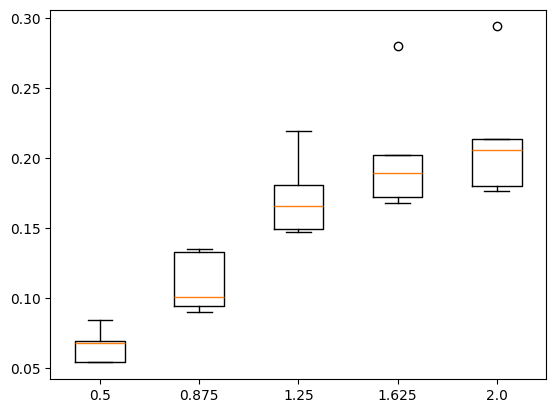

In [5]:
# contrast

params_space = [
    {'contrast': c} for c in np.linspace(0.5, 2.0, 5, endpoint=True)
]

params_space = list(
    map(lambda preprocess_args: Params(
        win_width=5,
        font_path=FONT_PATH,
        font_size=FONT_SIZE,
        converter_args={},
        preprocess_args=preprocess_args),
        params_space))

similarity_scores = test_loop(IMG_PATHS, make_converter, params_space)

plt.boxplot(similarity_scores,
            labels=[param.preprocess_args['contrast'] for param in params_space])
plt.show()